# Content-Based Filtering on MovieLens 100K

This notebook implements a content-based recommender using MovieLens 100K features (titles + genres). It trains on a per-user train/test split, builds item feature vectors (TF-IDF on titles + genre one-hot), constructs user profiles from rated items, predicts ratings using similarity-weighted ratings from user's rated items, and evaluates using RMSE/MAE and Precision@K/Recall@K. Plots are included.

In [1]:
# 1 — Imports & configuration
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Notebook magic (uncomment when running in a notebook)
# %matplotlib inline

DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
DATA_DIR = Path("./ml-100k")
MOVIE_FILE = DATA_DIR / "u.item"   # movie metadata
RATING_FILE = DATA_DIR / "u.data"
TEST_FRAC = 0.2
EVAL_TOPN = 10
EVAL_KS = [5, 10, 20]  # number of similar rated items to use in prediction/recommendation
SEED = 42
np.random.seed(SEED)

print('Config: TEST_FRAC=', TEST_FRAC, 'TOPN=', EVAL_TOPN, 'EVAL_KS=', EVAL_KS)

Config: TEST_FRAC= 0.2 TOPN= 10 EVAL_KS= [5, 10, 20]


In [2]:
# 2 — Download MovieLens 100K (if needed) and load ratings & movie metadata
if not DATA_DIR.exists() or not RATING_FILE.exists() or not MOVIE_FILE.exists():
    print("Downloading MovieLens 100K...")
    zip_path = Path("ml-100k.zip")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    import zipfile
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    zip_path.unlink()
    print("Downloaded and extracted.")
else:
    print("Dataset found at", DATA_DIR)

# Load ratings (u.data): user_id \t item_id \t rating \t timestamp
cols = ["user_id", "item_id", "rating", "timestamp"]
ratings = pd.read_csv(RATING_FILE, sep="\t", names=cols, engine="python")
ratings = ratings.drop(columns=["timestamp"])
ratings["user"] = "u" + ratings["user_id"].astype(str)
ratings["item"] = "i" + ratings["item_id"].astype(str)
ratings = ratings[["user", "item", "rating"]]
print(f"Loaded {len(ratings)} ratings: {ratings['user'].nunique()} users, {ratings['item'].nunique()} items")

# Load movie metadata (u.item): movie id | title | release date | video release date | URL | genres (19 flags)
# u.item is pipe-separated; some titles contain special characters
movie_cols = ['movie_id','title','release_date','video_release_date','url'] + [f'genre_{i}' for i in range(19)]
movies = pd.read_csv(MOVIE_FILE, sep='|', names=movie_cols, encoding='latin-1', engine='python')
movies['item'] = 'i' + movies['movie_id'].astype(str)
movies = movies[['item','title'] + [c for c in movie_cols if c.startswith('genre_')]]
# Build genres string from genre flags
genre_cols = [c for c in movies.columns if c.startswith('genre_')]
def genres_to_text(row):
    genres = [str(i) for i, c in enumerate(genre_cols) if row[c] == 1]
    return ' '.join(genres)
movies['genres_text'] = movies.apply(genres_to_text, axis=1)

print('Loaded', len(movies), 'movies')

Downloaded and extracted.
Loaded 100000 ratings: 943 users, 1682 items
Loaded 1682 movies


In [3]:
# 3 — Train/test split per user (leave at least 1 per user for test)
def train_test_split_per_user(df, test_frac=TEST_FRAC, seed=SEED):
    np.random.seed(seed)
    train_rows = []
    test_rows = []
    for u, g in df.groupby('user'):
        g_shuf = g.sample(frac=1.0, random_state=seed)
        n = len(g_shuf)
        if n == 0: continue
        test_n = max(1, int(np.floor(n * test_frac)))
        test_rows.append(g_shuf.iloc[:test_n])
        if n - test_n > 0:
            train_rows.append(g_shuf.iloc[test_n:])
    train_df = pd.concat(train_rows).reset_index(drop=True)
    test_df = pd.concat(test_rows).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = train_test_split_per_user(ratings)
print('Train ratings:', len(train_df), 'Test ratings:', len(test_df))

Train ratings: 80367 Test ratings: 19633


In [4]:
# 4 — Build item feature vectors: TF-IDF on titles + genre one-hot concatenation
from sklearn.preprocessing import normalize

# Merge train/test item lists with movies to ensure coverage
all_items = sorted(ratings['item'].unique())
movies_sub = movies[movies['item'].isin(all_items)].set_index('item')

# Prepare textual feature: title (TF-IDF)
titles = movies_sub['title'].fillna('').astype(str).values
tfidf = TfidfVectorizer(stop_words='english', max_features=2000)
title_feats = tfidf.fit_transform(titles)  # shape: (n_items, n_title_feats)

# Prepare genre features (19 flags -> as numeric columns)
genre_flags = movies_sub[genre_cols].fillna(0).astype(int).values  # shape: (n_items, 19)

# Combine features: horizontal stack (sparse + dense -> convert dense to sparse)
from scipy.sparse import hstack, csr_matrix
genre_sparse = csr_matrix(genre_flags)
item_features = hstack([title_feats, genre_sparse]).tocsr()  # final item feature matrix

print('Item features shape:', item_features.shape)

Item features shape: (1682, 2019)


In [5]:
# 5 — Precompute item-item similarity matrix (cosine on feature vectors)
# For ~1682 items this is fine (dense similarity matrix ~ (1682^2) floats)
print('Computing item-item cosine similarity (this may take a few seconds)...')
t0 = __import__('time').time()
item_sim_matrix = cosine_similarity(item_features, dense_output=True)
t1 = __import__('time').time()
print(f'Computed item-item similarity in {t1-t0:.2f}s')

Computing item-item cosine similarity (this may take a few seconds)...
Computed item-item similarity in 0.06s


In [6]:
# 6 — Precompute mappings for fast prediction
# Map items to index in our item_features ordering
item_list = movies_sub.index.tolist()  # same order as title_feats input
item_to_idx = {it: idx for idx, it in enumerate(item_list)}
idx_to_item = {idx: it for it, idx in item_to_idx.items()}

# user -> (rated_item_indices, ratings)
user_profiles = {}
for u, g in train_df.groupby('user'):
    # only keep rated items that exist in item_to_idx
    idxs = [item_to_idx[it] for it in g['item'] if it in item_to_idx]
    ratings_arr = [float(r) for it, r in zip(g['item'], g['rating']) if it in item_to_idx]
    if len(idxs) == 0:
        continue
    user_profiles[u] = (np.array(idxs, dtype=int), np.array(ratings_arr, dtype=float))

print('Built user_profiles for', len(user_profiles), 'users')

Built user_profiles for 943 users


In [7]:
# 7 — Prediction: similarity-weighted rating from user's rated items (content-based)
# For a target (user, item): compute similarities between target item and items the user rated,
# pick top-K most similar rated items, and do weighted average of the user's ratings (weights=similarities).
def predict_cbf(user, item, K=10, shrinkage=0.0):
    if user not in user_profiles or item not in item_to_idx:
        return np.nan
    rated_idxs, rated_ratings = user_profiles[user]
    target_idx = item_to_idx[item]
    sims = item_sim_matrix[target_idx, rated_idxs]  # similarities to items user rated
    # if all zeros or no overlap, return NaN
    if sims.size == 0:
        return np.nan
    # choose top-K similar rated items
    top_k_idx = np.argsort(-sims)[:K]
    chosen_sims = sims[top_k_idx]
    chosen_ratings = rated_ratings[top_k_idx]
    denom = np.abs(chosen_sims).sum() + shrinkage
    if denom == 0:
        return np.nan
    pred = (chosen_sims * chosen_ratings).sum() / denom
    return float(pred)

In [8]:
# 8 — Evaluate rating prediction (RMSE, MAE) for different K values
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_rating_pred(test_df, K=10):
    y_true = []
    y_pred = []
    for _, row in test_df.iterrows():
        u, it, r = row['user'], row['item'], row['rating']
        p = predict_cbf(u, it, K=K)
        # fallback to user's mean in train or global mean
        if np.isnan(p):
            p = train_df[train_df['user'] == u]['rating'].mean() if len(train_df[train_df['user'] == u]) > 0 else train_df['rating'].mean()
        y_true.append(r); y_pred.append(p)
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae, 'n': len(y_true)}

results = []
for K in EVAL_KS:
    res = evaluate_rating_pred(test_df, K=K)
    print(f'K={K}: RMSE={res["rmse"]:.4f}, MAE={res["mae"]:.4f}')
    results.append((K, res['rmse'], res['mae']))

res_df = pd.DataFrame(results, columns=['K','RMSE','MAE'])

K=5: RMSE=1.0820, MAE=0.8520
K=10: RMSE=1.0415, MAE=0.8269
K=20: RMSE=1.0258, MAE=0.8166


In [9]:
# 9 — Top-N evaluation: Precision@K and Recall@K for content-based recommendations
def recommend_top_n_cbf(user, K=10, top_n=EVAL_TOPN):
    if user not in user_profiles:
        return []
    rated_idxs, rated_ratings = user_profiles[user]
    seen = set([idx_to_item[i] for i in rated_idxs])
    # score all items user hasn't rated by similarity-weighted rating
    scores = []
    for it in item_list:
        if it in seen: continue
        p = predict_cbf(user, it, K=K)
        scores.append((it, p if not np.isnan(p) else -999))
    scores.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scores[:top_n]]

def precision_recall_cbf(test_df, K=10, top_n=EVAL_TOPN):
    precisions = []
    recalls = []
    users_eval = 0
    for u in sorted(set(train_df['user']).intersection(set(test_df['user']))):
        true_items = set(test_df[test_df['user'] == u]['item'])
        if len(true_items) == 0: continue
        recs = recommend_top_n_cbf(u, K=K, top_n=top_n)
        hit = len(set(recs) & true_items)
        precisions.append(hit / top_n)
        recalls.append(hit / len(true_items))
        users_eval += 1
    return {'precision': float(np.mean(precisions) if precisions else 0.0),
            'recall': float(np.mean(recalls) if recalls else 0.0),
            'users_eval': users_eval}

pr_results = []
for K in EVAL_KS:
    pr = precision_recall_cbf(test_df, K=K, top_n=EVAL_TOPN)
    print(f'K={K}: Precision@{EVAL_TOPN}={pr["precision"]:.4f}, Recall@{EVAL_TOPN}={pr["recall"]:.4f}')
    pr_results.append((K, pr['precision'], pr['recall']))

pr_df = pd.DataFrame(pr_results, columns=['K','Precision','Recall'])

K=5: Precision@10=0.0207, Recall@10=0.0097
K=10: Precision@10=0.0187, Recall@10=0.0068
K=20: Precision@10=0.0145, Recall@10=0.0046


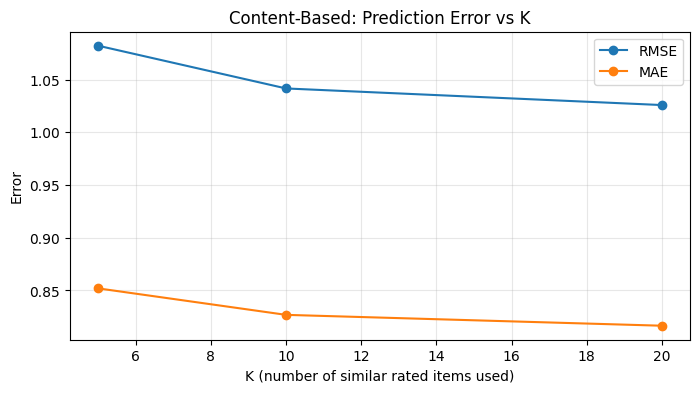

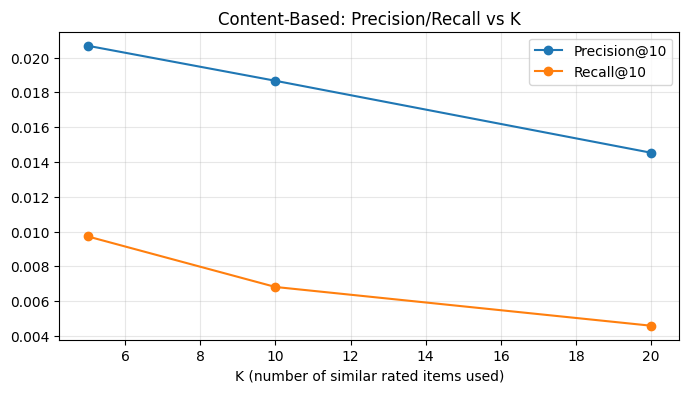

In [10]:
# 10 — Plots: RMSE/MAE vs K and Precision/Recall vs K
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(res_df['K'], res_df['RMSE'], marker='o', label='RMSE')
plt.plot(res_df['K'], res_df['MAE'], marker='o', label='MAE')
plt.xlabel('K (number of similar rated items used)')
plt.ylabel('Error')
plt.title('Content-Based: Prediction Error vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(pr_df['K'], pr_df['Precision'], marker='o', label=f'Precision@{EVAL_TOPN}')
plt.plot(pr_df['K'], pr_df['Recall'], marker='o', label=f'Recall@{EVAL_TOPN}')
plt.xlabel('K (number of similar rated items used)')
plt.title('Content-Based: Precision/Recall vs K')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [11]:
# 11 — Save evaluation summary and show examples
res_df.to_csv('cbf_rating_eval_summary.csv', index=False)
pr_df.to_csv('cbf_topn_eval_summary.csv', index=False)
print('Saved cbf_rating_eval_summary.csv and cbf_topn_eval_summary.csv')

# Show sample recommendations for a few users
for u in list(user_profiles.keys())[:5]:
    print('\\nUser', u)
    print('  Top-5 CBF recs:', recommend_top_n_cbf(u, K=EVAL_KS[1], top_n=5))

Saved cbf_rating_eval_summary.csv and cbf_topn_eval_summary.csv
\nUser u1
  Top-5 CBF recs: ['i488', 'i1476', 'i720', 'i857', 'i1594']
\nUser u10
  Top-5 CBF recs: ['i914', 'i646', 'i1669', 'i327', 'i1064']
\nUser u100
  Top-5 CBF recs: ['i1373', 'i32', 'i48', 'i75', 'i119']
\nUser u101
  Top-5 CBF recs: ['i593', 'i611', 'i1064', 'i1065', 'i1187']
\nUser u102
  Top-5 CBF recs: ['i1476', 'i1582', 'i488', 'i1232', 'i1123']
